source code: https://github.com/magicleap/SuperGluePretrainedNetwork/tree/master

download the following directories to local

models/ and assets/freiburg_sequence

In [ ]:
from pathlib import Path
import argparse
import cv2
import matplotlib.cm as cm
import torch
%matplotlib inline
import matplotlib.pyplot as plt

from models.matching import Matching
from models.utils import (AverageTimer, VideoStreamer,
                          make_matching_plot_fast, frame2tensor)

torch.set_grad_enabled(False)

In [ ]:
device = 'cuda' if torch.cuda.is_available() and not opt.force_cpu else 'cpu'
print('Running inference on device \"{}\"'.format(device))
config = {
    'superpoint': {
        'nms_radius': 4,
        'keypoint_threshold': 0.005,
        'max_keypoints': -1
    },
    'superglue': {
        'weights': 'indoor',
        'sinkhorn_iterations': 20,
        'match_threshold': 0.2,
    }
}

matching = Matching(config).eval().to(device)
keys = ['keypoints', 'scores', 'descriptors']

vs = VideoStreamer('assets/freiburg_sequence/', [640, 480], 1,
                    ['*.png', '*.jpg', '*.jpeg'], 5)
frame, ret = vs.next_frame()
assert ret, 'Error when reading the first frame (try different --input?)'

frame_tensor = frame2tensor(frame, device)
last_data = matching.superpoint({'image': frame_tensor})
last_data = {k+'0': last_data[k] for k in keys}
last_data['image0'] = frame_tensor
last_frame = frame
last_image_id = 0

Running inference on device "cpu"
Loaded SuperPoint model
Loaded SuperGlue model ("indoor" weights)
==> Processing image directory input: assets/freiburg_sequence/


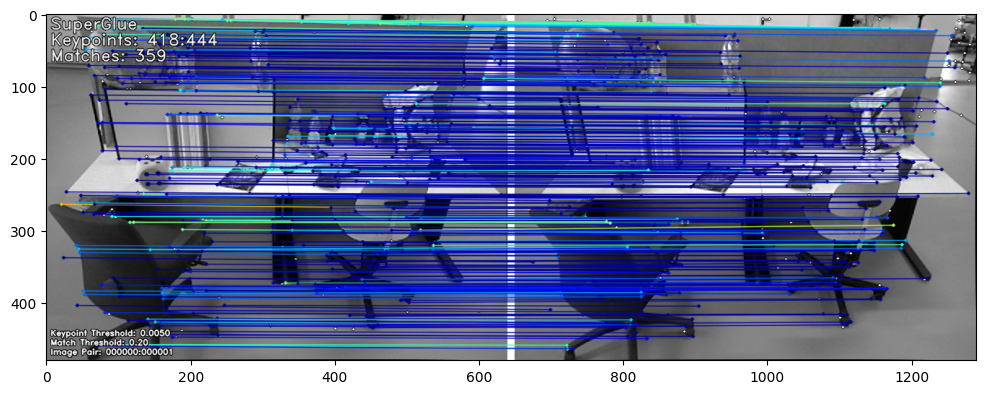

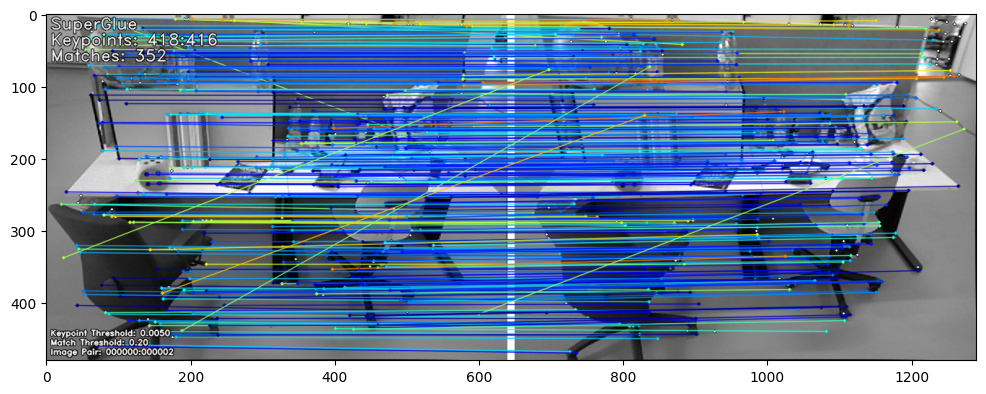

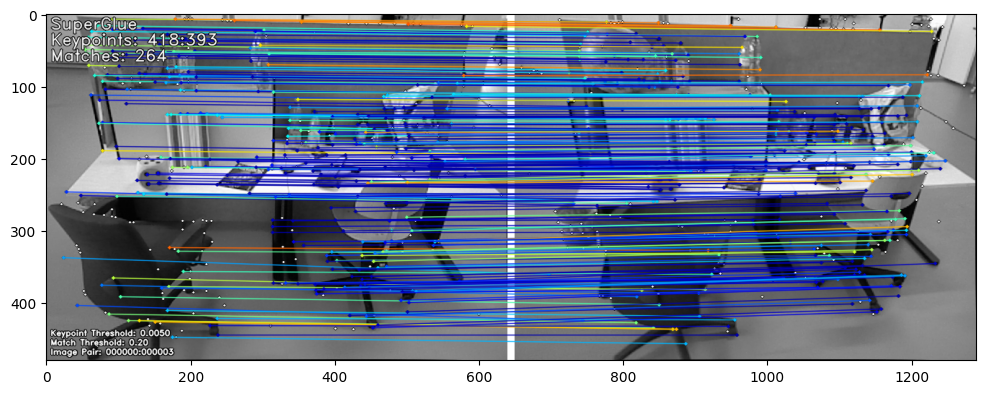

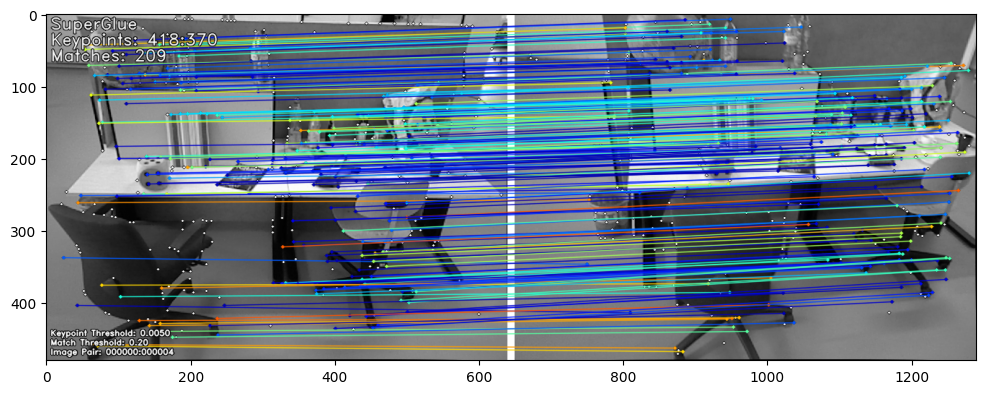

Finished demo_superglue.py


In [ ]:
timer = AverageTimer()

while True:
    frame, ret = vs.next_frame()
    if not ret:
        print('Finished demo_superglue.py')
        break
    timer.update('data')
    stem0, stem1 = last_image_id, vs.i - 1

    frame_tensor = frame2tensor(frame, device)
    pred = matching({**last_data, 'image1': frame_tensor})
    kpts0 = last_data['keypoints0'][0].cpu().numpy()
    kpts1 = pred['keypoints1'][0].cpu().numpy()
    matches = pred['matches0'][0].cpu().numpy()
    confidence = pred['matching_scores0'][0].cpu().numpy()
    timer.update('forward')

    valid = matches > -1
    mkpts0 = kpts0[valid]
    mkpts1 = kpts1[matches[valid]]
    color = cm.jet(confidence[valid])
    text = [
        'SuperGlue',
        'Keypoints: {}:{}'.format(len(kpts0), len(kpts1)),
        'Matches: {}'.format(len(mkpts0))
    ]
    k_thresh = matching.superpoint.config['keypoint_threshold']
    m_thresh = matching.superglue.config['match_threshold']
    small_text = [
        'Keypoint Threshold: {:.4f}'.format(k_thresh),
        'Match Threshold: {:.2f}'.format(m_thresh),
        'Image Pair: {:06}:{:06}'.format(stem0, stem1),
    ]
    out = make_matching_plot_fast(
        last_frame, frame, kpts0, kpts1, mkpts0, mkpts1, color, text,
        path=None, show_keypoints=True, small_text=small_text)

    plt.figure(figsize=(12,8))
    plt.imshow(out)
    plt.show()